# Phantom Array Effect — EEG & Saccade Analysis Pipeline

This notebook implements a complete 7-stage physiological analysis pipeline for the **phantom array effect** visual illusion experiment. The experiment investigates visual cortex entrainment dynamics during rapid saccadic eye movements.

### Key Objectives:
1. **Discover and Group** raw subject `.set` and `.fdt` files automatically.
2. **Preprocess and Filter** EEG and EOG signals, checking for baseline drifts.
3. **Detect Saccades** on smoothed EOG velocity using 4 rigorous, morphologically-guided quality gates.
4. **Extract SSVEP SNR** (signal-to-noise ratio) and harmonics ($2f_0$, $3f_0$) across occipital channels using a sliding window.
5. **Segment and Compare** temporal epochs (T1, T2, T3 thirds), analyzing linear trends and step-changes.
6. **Integrate Physiological Modalities** by analyzing correlations and cross-correlation lags between visual entrainment (EEG SNR) and motor tracking (EOG saccade rate).
7. **Generate and Render** high-resolution inline figures and diagnostic reports.


## Imports & Configuration
We load standard neurophysiological packages (`mne`), computational packages (`numpy`, `scipy`, `pandas`), and configure inline rendering.


In [1]:
%matplotlib inline
import os
import re
import glob
import logging
import traceback
import numpy as np
import scipy.signal
import scipy.stats
import mne
import matplotlib.pyplot as plt
import pandas as pd

# Setup inline plotting size and style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linestyle'] = ':'
plt.rcParams['grid.alpha'] = 0.6

# Directory configurations
DATA_DIR = "../../../data"  # Relative to src/python/phantom-array-experiment
OUTPUT_DIR = "./output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Imports completed successfully. Data directory:", DATA_DIR)


Imports completed successfully. Data directory: ../../../data


### Filename Parsing Helper
We parse the subject name and the stimulus frequency $f_0$ from the file name according to the naming convention: `<subject_name>-<OriginalFileName>.set`.


In [2]:
def parse_f0_from_filename(filename):
    basename = os.path.basename(filename)
    parts = basename.split('-', 1)
    if len(parts) < 2:
        raise ValueError(f"Filename '{basename}' does not follow convention <subject_name>-<OriginalFileName>.set")
    
    subject_name = parts[0]
    f0_part = parts[1]
    
    if f0_part.lower().endswith('.set'):
        f0_part = f0_part[:-4]
        
    match = re.match(r'^(\d+(?:\.\d+)?)', f0_part)
    if not match:
        raise ValueError(f"No leading numeric token in f0 string '{f0_part}'")
    
    val = float(match.group(1))
    
    # 4kHz -> 4000 Hz, etc.
    if 'khz' in f0_part.lower():
        f0 = val * 1000.0
    else:
        f0 = val
        
    return subject_name, f0


## Stage 0: File Discovery & Validation
We scan the data folder, check for the mandatory `.fdt` binary data files, parse the filename metadata, and assign conditions (`green_only` vs `red_green`) using text heuristics or EOG RMS (root mean square) values.


In [3]:
set_pattern_1 = os.path.join(DATA_DIR, "*.set")
set_pattern_2 = os.path.join(DATA_DIR, "*", "*.set")
set_files = glob.glob(set_pattern_1) + glob.glob(set_pattern_2)
set_files = sorted(list(set(set_files)))

valid_sessions = []
skipped_files = []

for f in set_files:
    basename = os.path.basename(f)
    fdt_path = f.replace('.set', '.fdt')
    
    if not os.path.exists(fdt_path):
        print(f"[STAGE 0 ERROR] Paired .fdt missing for '{basename}'. Skipping.")
        skipped_files.append((f, "MISSING_FDT"))
        continue
        
    try:
        subject, f0 = parse_f0_from_filename(f)
        valid_sessions.append({
            'path': f,
            'basename': basename,
            'subject': subject,
            'f0': f0
        })
    except Exception as e:
        print(f"[STAGE 0 ERROR] Failed to parse subject/f0 from '{basename}': {e}. Skipping.")
        skipped_files.append((f, "PARSE_ERROR"))

# Group sessions by subject
subjects_dict = {}
for s in valid_sessions:
    subj = s['subject']
    if subj not in subjects_dict:
        subjects_dict[subj] = []
    subjects_dict[subj].append(s)

# Group and label conditions
final_subjects_sessions = {}
for subj, sessions in subjects_dict.items():
    labeled = {'green_only': None, 'red_green': None}
    unlabeled = []
    
    for s in sessions:
        bname = s['basename'].lower()
        if any(k in bname for k in ['green_only', 'green', 'fixation']):
            labeled['green_only'] = s
        elif any(k in bname for k in ['red_green', 'red', 'rg', 'tracking']):
            labeled['red_green'] = s
        else:
            unlabeled.append(s)
            
    # Resolve ambiguous naming using EOG RMS
    if len(unlabeled) > 0:
        if len(unlabeled) == 1 and len(sessions) == 1:
            s = unlabeled[0]
            try:
                raw_temp = mne.io.read_raw_eeglab(s['path'], preload=True, verbose=False)
                eog_data_temp = raw_temp.copy().pick(['EOG']).filter(0.5, 30.0, verbose=False).get_data()[0] * 1e6
                rms = np.sqrt(np.mean(eog_data_temp**2))
                s['eog_rms'] = rms
                if rms > 50.0:
                    labeled['red_green'] = s
                else:
                    labeled['green_only'] = s
            except Exception as e:
                labeled['red_green'] = s # default fallback
        elif len(unlabeled) == 2:
            s1, s2 = unlabeled[0], unlabeled[1]
            try:
                raw1 = mne.io.read_raw_eeglab(s1['path'], preload=True, verbose=False)
                rms1 = np.sqrt(np.mean((raw1.copy().pick(['EOG']).filter(0.5, 30.0, verbose=False).get_data()[0] * 1e6)**2))
                raw2 = mne.io.read_raw_eeglab(s2['path'], preload=True, verbose=False)
                rms2 = np.sqrt(np.mean((raw2.copy().pick(['EOG']).filter(0.5, 30.0, verbose=False).get_data()[0] * 1e6)**2))
                s1['eog_rms'] = rms1
                s2['eog_rms'] = rms2
                if rms1 > rms2:
                    labeled['red_green'] = s1
                    labeled['green_only'] = s2
                else:
                    labeled['red_green'] = s2
                    labeled['green_only'] = s1
            except Exception as e:
                labeled['red_green'] = s1
                labeled['green_only'] = s2
                
    final_subjects_sessions[subj] = labeled

# Print summary table
print("\n" + "="*70)
print(f"{'Subject':<15} | {'Green-only (Fixation)':<25} | {'Red+Green (Tracking)':<25}")
print("="*70)
for subj, conds in final_subjects_sessions.items():
    g_name = conds['green_only']['basename'] if conds['green_only'] else "MISSING"
    rg_name = conds['red_green']['basename'] if conds['red_green'] else "MISSING"
    print(f"{subj:<15} | {g_name:<25} | {rg_name:<25}")
print("="*70)


[STAGE 0 ERROR] Paired .fdt missing for '80O.set'. Skipping.
[STAGE 0 ERROR] Paired .fdt missing for '0O.set'. Skipping.
[STAGE 0 ERROR] Paired .fdt missing for '160O.set'. Skipping.
[STAGE 0 ERROR] Paired .fdt missing for '80O.set'. Skipping.
[STAGE 0 ERROR] Paired .fdt missing for '緑なし.set'. Skipping.


/Users/jikaewsi/miniforge3/envs/tokai-lab/lib/python3.14/site-packages/pymatreader/utils.py:225: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(
/Users/jikaewsi/miniforge3/envs/tokai-lab/lib/python3.14/site-packages/pymatreader/utils.py:225: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(



Subject         | Green-only (Fixation)     | Red+Green (Tracking)     
yamashita       | MISSING                   | yamashita-80O.set        


## Stage 1: Load & Preprocess
We load the raw dataset for demonstration. We will select the active tracking **`red_green`** condition for subject **`yamashita`**.
We then verify channel layouts, apply notch filters (50 Hz and 100 Hz), broadband filter EEG channels (0.5 - 80 Hz), extract and scale the EOG channel to microvolts ($\mu	ext{V}$), check for linear baseline drifts, and adjust EOG high-pass cutoffs if drift exceeds $5\ \mu	ext{V/s}$.


In [4]:
# Select subject yamashita Red+Green condition for analysis
target_subj = 'yamashita'
session = final_subjects_sessions[target_subj]['red_green']
if not session:
    raise ValueError(f"Red+Green condition not found for subject {target_subj}")

cond_path = session['path']
f0 = session['f0']

print(f"Loading '{os.path.basename(cond_path)}'...")
raw = mne.io.read_raw_eeglab(cond_path, preload=True)
sfreq = raw.info['sfreq']
n_samples = raw.n_times
duration = raw.times[-1]

# Verify channel counts
assert 'EOG' in raw.ch_names, "EOG channel not found!"
occ_channels = [ch for ch in ['PO7', 'O1', 'Oz', 'O2', 'PO8'] if ch in raw.ch_names]
front_channels = [ch for ch in ['F3', 'Fz', 'F4'] if ch in raw.ch_names]
print(f"Found occipital channels: {occ_channels}")
print(f"Found frontal channels: {front_channels}")

# Notch filter
notch_freqs = [50.0]
if sfreq > 200.0:
    notch_freqs.append(100.0)
print(f"Applying notch filter at {notch_freqs} Hz")
raw.notch_filter(freqs=notch_freqs, verbose=False)

# EEG broadband filter
high_cutoff = 80.0
if f0 > 80.0:
    high_cutoff = min(f0 * 1.5, sfreq / 2.0 - 1.0)
print(f"Applying EEG bandpass: 0.5 - {high_cutoff:.1f} Hz")
eeg_picks = [ch for ch in raw.ch_names if ch != 'EOG']
raw.filter(l_freq=0.5, h_freq=high_cutoff, picks=eeg_picks, verbose=False)

# EOG baseline drift check
raw_eog_data = raw.copy().pick(['EOG']).get_data()[0] * 1e6 # uV
slope, intercept, r_val, p_val, std_err = scipy.stats.linregress(raw.times, raw_eog_data)

eog_mne = raw.copy().pick(['EOG'])
eog_mne._data[0] = eog_mne._data[0] * 1e6 # Scale to uV

if abs(slope) > 5.0:
    print(f"[WARNING] EOG baseline drift is {slope:.2f} uV/s (> 5 uV/s). Applying 0.1 Hz high-pass EOG filter.")
    eog_mne.filter(l_freq=0.1, h_freq=30.0, verbose=False)
else:
    print(f"EOG baseline drift is {slope:.2f} uV/s (<= 5 uV/s). Applying standard 0.5 - 30 Hz EOG filter.")
    eog_mne.filter(l_freq=0.5, h_freq=30.0, verbose=False)

eog_filtered = eog_mne.get_data()[0] # shape (n_samples,)


Loading 'yamashita-80O.set'...
Found occipital channels: ['PO7', 'O1', 'Oz', 'O2', 'PO8']
Found frontal channels: ['F3', 'Fz', 'F4']
Applying notch filter at [50.0, 100.0] Hz
Applying EEG bandpass: 0.5 - 80.0 Hz
EOG baseline drift is 0.02 uV/s (<= 5 uV/s). Applying standard 0.5 - 30 Hz EOG filter.


/Users/jikaewsi/miniforge3/envs/tokai-lab/lib/python3.14/site-packages/pymatreader/utils.py:225: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(
/Users/jikaewsi/miniforge3/envs/tokai-lab/lib/python3.14/site-packages/pymatreader/utils.py:225: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(


## Stage 2: Saccade Detection
We compute smoothed EOG velocity, establish statistical velocity thresholds, find local velocity peaks, and apply 4 rigorous quality gates to filter out outlier movement spikes and muscle artifacts:
1. **Gate 4 (Global IQR Outlier)**: Rejects velocity peaks exceeding the Interquartile Range outlier threshold.
2. **Gate 1 (Single-peak velocity)**: Rejects velocity peaks with secondary peaks $> 40\%$ prominence in $\pm100	ext{ ms}$.
3. **Gate 2 (Post-saccade stability)**: Rejects events followed by high-variance drift within $200	ext{ ms}$.
4. **Gate 3 (Waveform monotonicity)**: Rejects high-frequency fluctuation returning to baseline ($>4$ sign changes in derivative in $300	ext{ ms}$).


In [5]:
# 2.1 Velocity computation
velocity = np.diff(eog_filtered) * sfreq
velocity = np.append(velocity, 0)
# 5-sample moving average smoother
velocity = np.convolve(velocity, np.ones(5)/5.0, mode='same')

# 2.2 Candidate peak detection
v_mean = np.mean(velocity)
v_std = np.std(velocity)
thresh = v_mean + 3.5 * v_std
thresh_neg = v_mean - 3.5 * v_std
max_thresh = max(abs(thresh), abs(thresh_neg))

min_dist_samp = int(0.15 * sfreq)
candidates, _ = scipy.signal.find_peaks(np.abs(velocity), height=max_thresh, distance=min_dist_samp)
print(f"Detected {len(candidates)} saccade candidates.")

# 2.3 Quality gates
saccade_rows = []

# Precompute Gate 4 parameters: Velocity outlier (global IQR)
if len(candidates) > 0:
    cand_velocities = np.abs(velocity[candidates])
    q25, q75 = np.percentile(cand_velocities, [25, 75])
    iqr = q75 - q25
    median_v = np.median(cand_velocities)
    upper_limit = median_v + 3 * iqr
else:
    upper_limit = np.inf

gate_counts = {'candidates': len(candidates), 'velocity_outlier': 0, 'multi_peak': 0, 'unstable_fixation': 0, 'non_monotonic': 0, 'passed': 0}
accepted_samples = []

for peak in candidates:
    peak_vel = velocity[peak]
    direction = 1 if peak_vel > 0 else -1
    
    # Gate 4: Velocity Outlier Check
    if np.abs(peak_vel) > upper_limit:
        gate_counts['velocity_outlier'] += 1
        saccade_rows.append({
            'onset_sample': int(peak), 'onset_ms': float(peak / sfreq * 1000.0),
            'direction': int(direction), 'peak_velocity': float(peak_vel),
            'isi_ms': np.nan, 'passed_gates': False, 'rejection_reason': 'velocity_outlier'
        })
        continue
        
    # Gate 1: Single-peak velocity shape (±100 ms)
    win_100ms = int(0.100 * sfreq)
    win_start = max(0, peak - win_100ms)
    win_end = min(n_samples, peak + win_100ms + 1)
    window_vel = np.abs(velocity[win_start:win_end])
    peaks_in_win, _ = scipy.signal.find_peaks(window_vel)
    global_peaks = win_start + peaks_in_win
    
    multi_peak_fail = False
    for gp in global_peaks:
        if abs(gp - peak) > int(0.005 * sfreq): # > 5ms away
            if np.abs(velocity[gp]) > 0.4 * np.abs(peak_vel):
                multi_peak_fail = True
                break
                
    if multi_peak_fail:
        gate_counts['multi_peak'] += 1
        saccade_rows.append({
            'onset_sample': int(peak), 'onset_ms': float(peak / sfreq * 1000.0),
            'direction': int(direction), 'peak_velocity': float(peak_vel),
            'isi_ms': np.nan, 'passed_gates': False, 'rejection_reason': 'multi_peak'
        })
        continue
        
    # Gate 2: Post-saccade fixation stability (200 ms)
    win_200ms = int(0.200 * sfreq)
    win_data = eog_filtered[peak : min(n_samples, peak + win_200ms)]
    win_var = np.var(win_data)
    global_std = np.std(eog_filtered)
    if win_var > (1.5 * global_std) ** 2:
        gate_counts['unstable_fixation'] += 1
        saccade_rows.append({
            'onset_sample': int(peak), 'onset_ms': float(peak / sfreq * 1000.0),
            'direction': int(direction), 'peak_velocity': float(peak_vel),
            'isi_ms': np.nan, 'passed_gates': False, 'rejection_reason': 'unstable_fixation'
        })
        continue
        
    # Gate 3: Waveform monotonicity (300 ms)
    win_300ms = int(0.300 * sfreq)
    deriv = np.diff(eog_filtered[peak : min(n_samples, peak + win_300ms)])
    sign_deriv = np.sign(deriv)
    sign_deriv = sign_deriv[sign_deriv != 0]
    sign_changes = np.sum(np.diff(sign_deriv) != 0)
    if sign_changes > 4:
        gate_counts['non_monotonic'] += 1
        saccade_rows.append({
            'onset_sample': int(peak), 'onset_ms': float(peak / sfreq * 1000.0),
            'direction': int(direction), 'peak_velocity': float(peak_vel),
            'isi_ms': np.nan, 'passed_gates': False, 'rejection_reason': 'non_monotonic'
        })
        continue
        
    # Passed all gates!
    gate_counts['passed'] += 1
    accepted_samples.append(peak)
    saccade_rows.append({
        'onset_sample': int(peak), 'onset_ms': float(peak / sfreq * 1000.0),
        'direction': int(direction), 'peak_velocity': float(peak_vel),
        'isi_ms': np.nan, 'passed_gates': True, 'rejection_reason': ''
    })

# Compute ISI (Inter-Saccade Interval)
saccades_df = pd.DataFrame(saccade_rows)
if len(saccades_df) > 0:
    passed_indices = saccades_df[saccades_df.passed_gates == True].index
    prev_onset_ms = np.nan
    for idx in passed_indices:
        curr_onset_ms = saccades_df.loc[idx, 'onset_ms']
        if not np.isnan(prev_onset_ms):
            saccades_df.loc[idx, 'isi_ms'] = curr_onset_ms - prev_onset_ms
        prev_onset_ms = curr_onset_ms

print("\n--- Saccade Detection summary ---")
print(f"Candidates before Gating: {gate_counts['candidates']}")
print(f"Rejected by Gate 4 (Velocity Outliers): {gate_counts['velocity_outlier']}")
print(f"Rejected by Gate 1 (Multi-Peak Shapes):  {gate_counts['multi_peak']}")
print(f"Rejected by Gate 2 (Unstable Fixation): {gate_counts['unstable_fixation']}")
print(f"Rejected by Gate 3 (Non-Monotonicity):  {gate_counts['non_monotonic']}")
print(f"Accepted Saccades: {gate_counts['passed']}")


Detected 65 saccade candidates.

--- Saccade Detection summary ---
Candidates before Gating: 65
Rejected by Gate 4 (Velocity Outliers): 0
Rejected by Gate 1 (Multi-Peak Shapes):  35
Rejected by Gate 2 (Unstable Fixation): 0
Rejected by Gate 3 (Non-Monotonicity):  9
Accepted Saccades: 21


## Stage 3: SSVEP Sliding-Window SNR
We compute the sliding-window Power Spectral Density (PSD) via `scipy.signal.welch` in 4.0-second windows with 1.0-second step size.
We extract the narrow-band SNR (in dB) around $f_0$, $2f_0$, and $3f_0$ by comparing the target signal energy against the local noise floor.
We then compute the **Lateral Asymmetry Index (LAI)** at each time point, measuring whether entrainment shifts from foveal (Oz) to lateral (PO7/PO8) regions:
$$	ext{LAI} = \frac{PO7_{	ext{SNR}} + PO8_{	ext{SNR}}}{2} - Oz_{	ext{SNR}}$$


In [6]:
WIN_SEC = 4.0
STEP_SEC = 1.0
NOISE_BW = 5.0
F0_TOL = 0.5

win_samp = int(WIN_SEC * sfreq)
step_samp = int(STEP_SEC * sfreq)
starts = np.arange(0, n_samples - win_samp + 1, step_samp)
t_centers = raw.times[starts + win_samp // 2]

n_ch = len(occ_channels)
snr_db = np.zeros((n_ch, len(starts)))
snr_2f0 = np.zeros((n_ch, len(starts)))
snr_3f0 = np.zeros((n_ch, len(starts)))

for ch_local_idx, ch_name in enumerate(occ_channels):
    ch_idx = raw.ch_names.index(ch_name)
    eeg_chan_data = raw.get_data(picks=[ch_idx])[0]
    
    for i, s in enumerate(starts):
        seg = eeg_chan_data[s : s + win_samp]
        freqs, psd = scipy.signal.welch(seg, fs=sfreq, nperseg=win_samp)
        
        # f0 SNR
        f0_mask = np.abs(freqs - f0) <= F0_TOL
        noise_mask = (np.abs(freqs - f0) > F0_TOL) & (np.abs(freqs - f0) <= NOISE_BW)
        signal_power = psd[f0_mask].mean()
        noise_power = psd[noise_mask].mean()
        snr_db[ch_local_idx, i] = 10 * np.log10(signal_power / (noise_power + 1e-12))
        
        # 2*f0 SNR
        if 2 * f0 < sfreq / 2:
            f0_mask_2 = np.abs(freqs - 2*f0) <= F0_TOL
            noise_mask_2 = (np.abs(freqs - 2*f0) > F0_TOL) & (np.abs(freqs - 2*f0) <= NOISE_BW)
            snr_2f0[ch_local_idx, i] = 10 * np.log10(psd[f0_mask_2].mean() / (psd[noise_mask_2].mean() + 1e-12))
            
        # 3*f0 SNR
        if 3 * f0 < sfreq / 2:
            f0_mask_3 = np.abs(freqs - 3*f0) <= F0_TOL
            noise_mask_3 = (np.abs(freqs - 3*f0) > F0_TOL) & (np.abs(freqs - 3*f0) <= NOISE_BW)
            snr_3f0[ch_local_idx, i] = 10 * np.log10(psd[f0_mask_3].mean() / (psd[noise_mask_3].mean() + 1e-12))

# Lateral Asymmetry Index (LAI)
lat_chans = [ch for ch in ['PO7', 'PO8'] if ch in occ_channels]
lat_idxs = [occ_channels.index(ch) for ch in lat_chans]
lateral = snr_db[lat_idxs].mean(axis=0) if len(lat_idxs) > 0 else np.zeros(len(starts))
oz_local_idx = occ_channels.index('Oz') if 'Oz' in occ_channels else 0
central = snr_db[oz_local_idx]
LAI = lateral - central

print(f"Extracted {len(starts)} SSVEP sliding windows.")
print(f"Occipital mean SNR at f0: {snr_db.mean():.2f} dB")
print(f"Lateral Asymmetry Index mean: {LAI.mean():.2f} dB")


Extracted 81 SSVEP sliding windows.
Occipital mean SNR at f0: -6.49 dB
Lateral Asymmetry Index mean: 1.54 dB


## Stage 4: Temporal Segmentation & Transitions
We split the session into equal thirds (T1, T2, T3) to observe mean SNR changes over time.
We then fit a linear trend to the Oz SNR trajectory (`scipy.stats.linregress`) to determine if it is monotonically increasing, decreasing, or non-monotonic.
We also perform a **sliding t-test** (comparing the 10 s before $t$ against the 10 s after $t$) to identify the step-change transition time ($t_{	ext{transition}}$), representing the estimated phantom array percept onset.


In [7]:
t1_mask = t_centers < duration / 3.0
t2_mask = (t_centers >= duration / 3.0) & (t_centers < 2 * duration / 3.0)
t3_mask = t_centers >= 2 * duration / 3.0

oz_snr = snr_db[oz_local_idx]
t1_mean = oz_snr[t1_mask].mean() if t1_mask.any() else np.nan
t2_mean = oz_snr[t2_mask].mean() if t2_mask.any() else np.nan
t3_mean = oz_snr[t3_mask].mean() if t3_mask.any() else np.nan
epoch_snr = np.array([t1_mean, t2_mean, t3_mean])

# Linear trend
slope, intercept, r_val, p_val, std_err = scipy.stats.linregress(t_centers, oz_snr)
trend_dir = 'non-monotonic' if p_val >= 0.05 else ('monotonically increasing' if slope > 0 else 'monotonically decreasing')

# Sliding t-test transition
best_t = np.nan
max_abs_t = -1.0
for t in t_centers:
    if 10.0 <= t <= duration - 10.0:
        before_vals = oz_snr[(t_centers >= t - 10.0) & (t_centers <= t)]
        after_vals = oz_snr[(t_centers >= t) & (t_centers <= t + 10.0)]
        if len(before_vals) > 1 and len(after_vals) > 1:
            t_stat, _ = scipy.stats.ttest_ind(after_vals, before_vals, equal_var=False)
            if np.abs(t_stat) > max_abs_t:
                max_abs_t = np.abs(t_stat)
                best_t = t
                
t_transition = best_t

print(f"Epoch thirds mean SNR: T1={t1_mean:.2f} dB, T2={t2_mean:.2f} dB, T3={t3_mean:.2f} dB")
print(f"Oz SSVEP Trend: slope={slope*1000:.4f} dB/ks, p={p_val:.4e} ({trend_dir})")
print(f"Step-change transition t_transition = {t_transition:.1f} s (max |t| = {max_abs_t:.2f})")


Epoch thirds mean SNR: T1=-7.42 dB, T2=-7.48 dB, T3=-7.08 dB
Oz SSVEP Trend: slope=9.2808 dB/ks, p=4.8189e-01 (non-monotonic)
Step-change transition t_transition = 65.0 s (max |t| = 3.17)


## Stage 5: Saccade–SSVEP Integration
We link EOG movement metrics with EEG cortical entrainment:
1. **ISI vs SNR Correlation**: Pearson and Spearman correlations between accepted saccade `isi_ms` and nearest-sample Oz SNR.
2. **Saccade Rate time series**: Saccades per second calculated in a rolling 10-second window.
3. **Cross-correlation**: Pearson correlation between the rolling saccade rate and Oz SNR at lags from $-10	ext{ s}$ to $+10	ext{ s}$.


In [8]:
accepted_sacc = saccades_df[saccades_df.passed_gates == True]

# 5.1 ISI vs SNR Correlation
isi_vals = []
snr_vals = []
for idx, row in accepted_sacc.iterrows():
    if not np.isnan(row.isi_ms):
        onset_sec = row.onset_ms / 1000.0
        nearest_idx = np.argmin(np.abs(t_centers - onset_sec))
        isi_vals.append(row.isi_ms)
        snr_vals.append(oz_snr[nearest_idx])
        
if len(isi_vals) > 2:
    pearson_r, pearson_p = scipy.stats.pearsonr(isi_vals, snr_vals)
    spearman_r, spearman_p = scipy.stats.spearmanr(isi_vals, snr_vals)
else:
    pearson_r, pearson_p = np.nan, np.nan
    spearman_r, spearman_p = np.nan, np.nan

# 5.2 Saccade rate time series (10 s window, 1 s step)
rate_ts = np.zeros(len(t_centers))
for i, t in enumerate(t_centers):
    window_saccades = accepted_sacc[
        (accepted_sacc.onset_ms >= (t - 5) * 1000) &
        (accepted_sacc.onset_ms <  (t + 5) * 1000)
    ]
    rate_ts[i] = len(window_saccades) / 10.0

# 5.3 Cross-correlation
lags = np.arange(-10, 11)
xcorr = np.zeros(len(lags))
for idx, lag in enumerate(lags):
    if lag > 0:
        xcorr[idx] = np.corrcoef(rate_ts[:-lag], oz_snr[lag:])[0, 1]
    elif lag < 0:
        xcorr[idx] = np.corrcoef(rate_ts[-lag:], oz_snr[:lag])[0, 1]
    else:
        xcorr[idx] = np.corrcoef(rate_ts, oz_snr)[0, 1]
        
peak_lag_idx = np.argmax(np.abs(xcorr))
peak_lag = lags[peak_lag_idx]

print("Physiological Integration statistics:")
print(f"  - ISI vs Oz SNR Pearson r: {pearson_r:.3f} (p={pearson_p:.4e})")
print(f"  - ISI vs Oz SNR Spearman r: {spearman_r:.3f} (p={spearman_p:.4e})")
print(f"  - Peak cross-correlation lag: {peak_lag} s (r = {xcorr[peak_lag_idx]:.3f})")


Physiological Integration statistics:
  - ISI vs Oz SNR Pearson r: 0.201 (p=3.9570e-01)
  - ISI vs Oz SNR Spearman r: 0.270 (p=2.4939e-01)
  - Peak cross-correlation lag: -7 s (r = 0.192)


## Stage 6: Visualization & Reporting
We render the four diagnostic figures inline to analyze our preprocessing, saccade gates, SSVEP SNR dynamics, LAI, cross-correlations, and thirds.


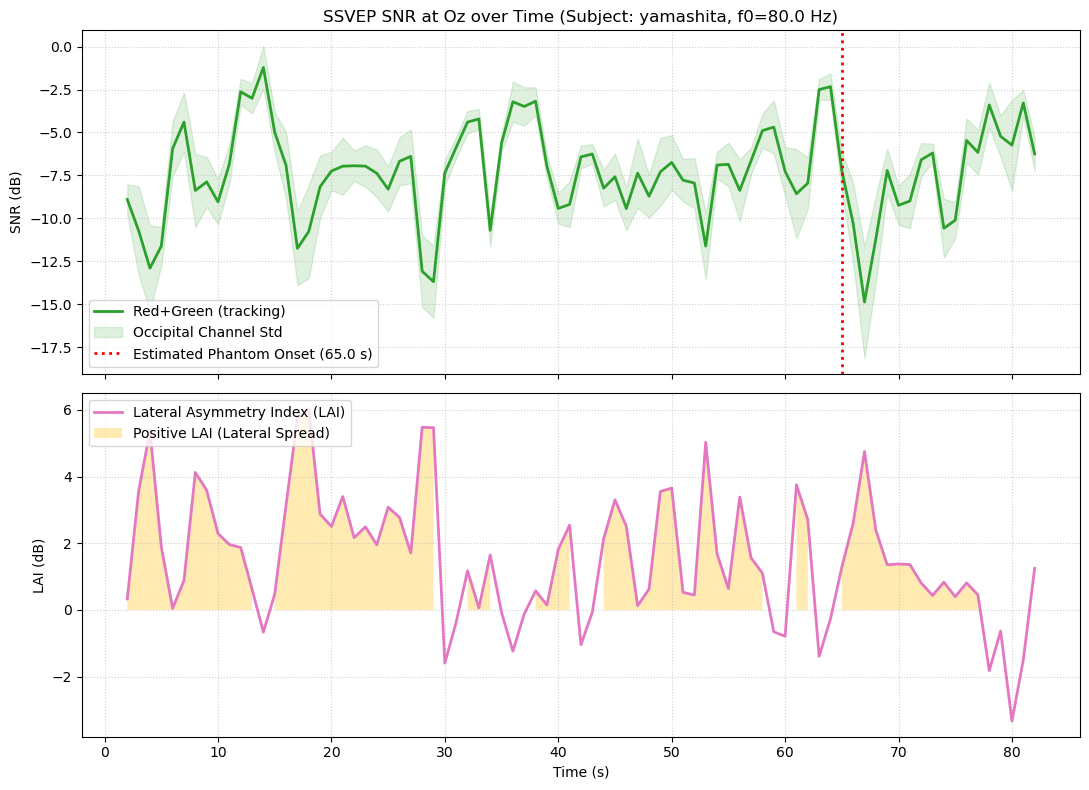

In [9]:
# Figure 1: SSVEP Trajectory and LAI
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Row 1: Oz SNR
axes[0].plot(t_centers, oz_snr, '-', color='#2ca02c', linewidth=2, label='Red+Green (tracking)')
snr_std = snr_db.std(axis=0)
axes[0].fill_between(t_centers, oz_snr - snr_std, oz_snr + snr_std, color='#2ca02c', alpha=0.15, label='Occipital Channel Std')

if not np.isnan(t_transition):
    axes[0].axvline(t_transition, color='red', linestyle=':', linewidth=2, label=f'Estimated Phantom Onset ({t_transition:.1f} s)')
    
axes[0].set_ylabel("SNR (dB)")
axes[0].set_title(f"SSVEP SNR at Oz over Time (Subject: {target_subj}, f0={f0} Hz)")
axes[0].grid(True)
axes[0].legend(loc='lower left')

# Row 2: LAI
axes[1].plot(t_centers, LAI, '-', color='#e377c2', linewidth=2, label='Lateral Asymmetry Index (LAI)')
axes[1].fill_between(t_centers, LAI, 0, where=(LAI > 0), facecolor='#FFBF00', alpha=0.3, label='Positive LAI (Lateral Spread)')
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("LAI (dB)")
axes[1].grid(True)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()


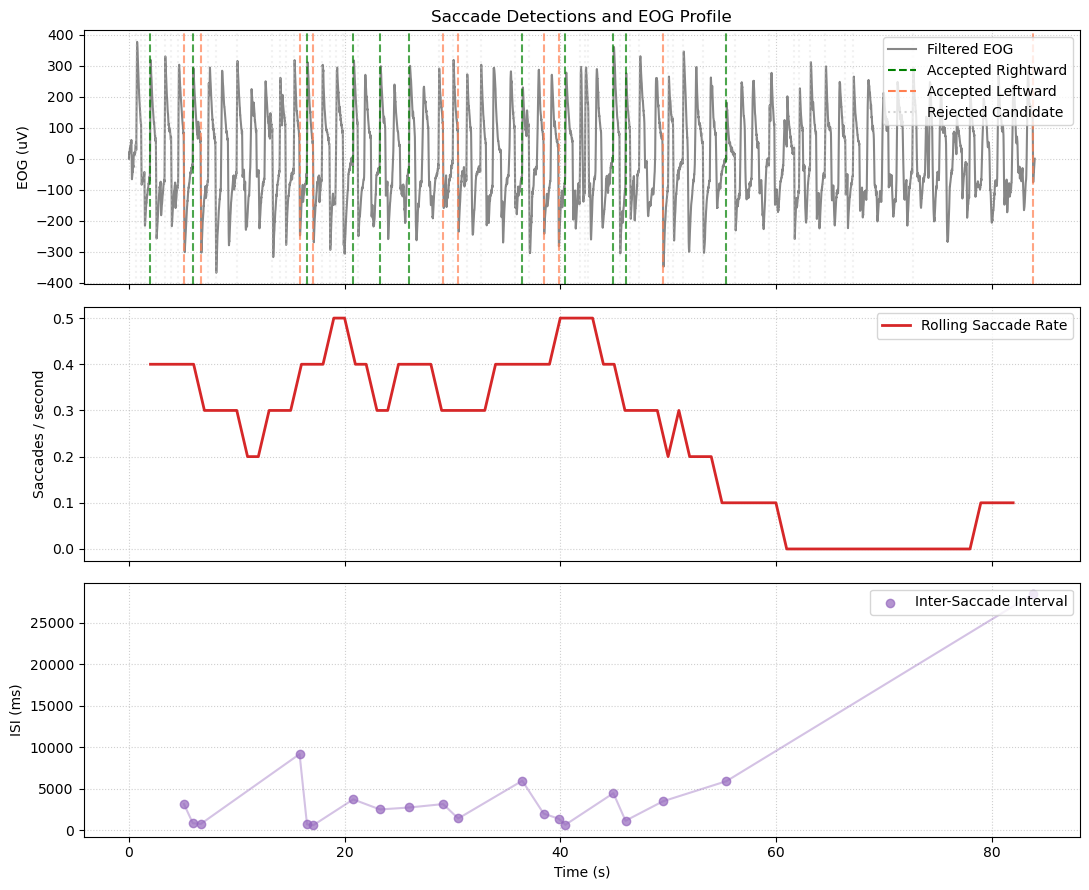

In [10]:
# Figure 2: Saccade Overview
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

# Row 1: Filtered EOG with detections
axes[0].plot(raw.times, eog_filtered, color='dimgray', alpha=0.8, label='Filtered EOG')

right_sacc = accepted_sacc[accepted_sacc.direction == 1]
left_sacc = accepted_sacc[accepted_sacc.direction == -1]

for _, row in right_sacc.iterrows():
    axes[0].axvline(row.onset_ms / 1000.0, color='green', alpha=0.7, linestyle='--')
for _, row in left_sacc.iterrows():
    axes[0].axvline(row.onset_ms / 1000.0, color='coral', alpha=0.7, linestyle='--')
    
rejected_sacc = saccades_df[saccades_df.passed_gates == False]
for _, row in rejected_sacc.iterrows():
    axes[0].axvline(row.onset_ms / 1000.0, color='lightgray', alpha=0.3, linestyle=':')

axes[0].plot([], [], color='green', linestyle='--', label='Accepted Rightward')
axes[0].plot([], [], color='coral', linestyle='--', label='Accepted Leftward')
axes[0].plot([], [], color='lightgray', linestyle=':', label='Rejected Candidate')
axes[0].set_ylabel("EOG (uV)")
axes[0].set_title("Saccade Detections and EOG Profile")
axes[0].legend(loc='upper right')
axes[0].grid(True)

# Row 2: Saccade rate
axes[1].plot(t_centers, rate_ts, '-', color='#d62728', linewidth=2, label='Rolling Saccade Rate')
axes[1].set_ylabel("Saccades / second")
axes[1].grid(True)
axes[1].legend(loc='upper right')

# Row 3: ISI
acc_sacc_with_isi = accepted_sacc[accepted_sacc.isi_ms.notna()]
axes[2].scatter(acc_sacc_with_isi.onset_ms / 1000.0, acc_sacc_with_isi.isi_ms, color='#9467bd', alpha=0.7, label='Inter-Saccade Interval')
axes[2].plot(acc_sacc_with_isi.onset_ms / 1000.0, acc_sacc_with_isi.isi_ms, '-', color='#9467bd', alpha=0.4)
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("ISI (ms)")
axes[2].grid(True)
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()


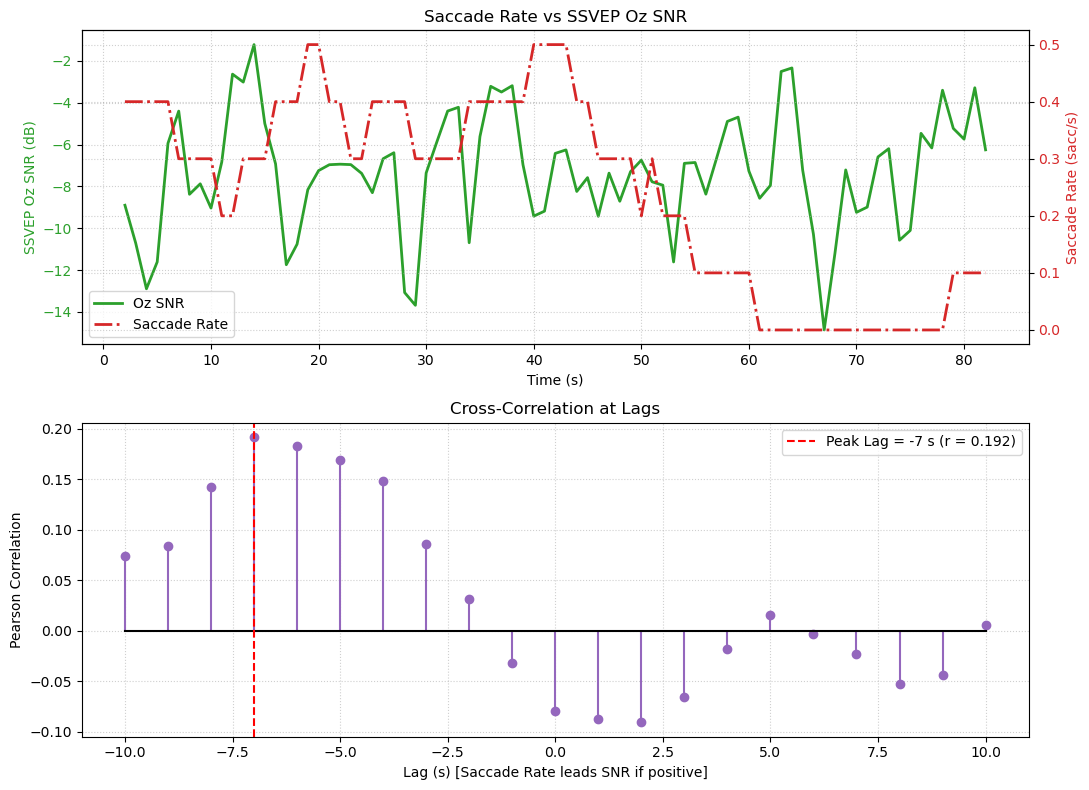

In [11]:
# Figure 3: SSVEP Oz SNR & Saccade Rate Integration
fig, axes = plt.subplots(2, 1, figsize=(11, 8))

# Row 1: Dual-y axis plot
color_snr = '#2ca02c'
color_rate = '#d62728'

axes[0].plot(t_centers, oz_snr, color=color_snr, linewidth=2, label='Oz SNR')
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("SSVEP Oz SNR (dB)", color=color_snr)
axes[0].tick_params(axis='y', labelcolor=color_snr)
axes[0].grid(True)

ax0_twin = axes[0].twinx()
ax0_twin.plot(t_centers, rate_ts, color=color_rate, linewidth=2, linestyle='-.', label='Saccade Rate')
ax0_twin.set_ylabel("Saccade Rate (sacc/s)", color=color_rate)
ax0_twin.tick_params(axis='y', labelcolor=color_rate)

lines, labels = axes[0].get_legend_handles_labels()
lines_twin, labels_twin = ax0_twin.get_legend_handles_labels()
axes[0].legend(lines + lines_twin, labels + labels_twin, loc='lower left')
axes[0].set_title("Saccade Rate vs SSVEP Oz SNR")

# Row 2: Cross-correlation stem
axes[1].stem(lags, xcorr, linefmt='C4-', markerfmt='C4o', basefmt='k-')
axes[1].axvline(peak_lag, color='red', linestyle='--', label=f'Peak Lag = {peak_lag} s (r = {xcorr[peak_lag_idx]:.3f})')
axes[1].set_xlabel("Lag (s) [Saccade Rate leads SNR if positive]")
axes[1].set_ylabel("Pearson Correlation")
axes[1].set_title("Cross-Correlation at Lags")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


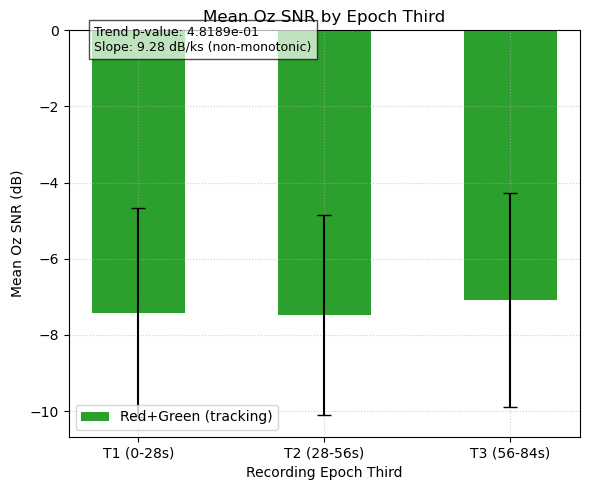

In [12]:
# Figure 4: Thirds Epoch Comparison
fig, ax = plt.subplots(figsize=(6, 5))
index = np.arange(3)

t1_std = oz_snr[t1_mask].std() if t1_mask.any() else 0.0
t2_std = oz_snr[t2_mask].std() if t2_mask.any() else 0.0
t3_std = oz_snr[t3_mask].std() if t3_mask.any() else 0.0
epoch_std = np.array([t1_std, t2_std, t3_std])

ax.bar(index, epoch_snr, 0.5, yerr=epoch_std, label='Red+Green (tracking)', color='#2ca02c', capsize=5, ecolor='black')
ax.set_xlabel("Recording Epoch Third")
ax.set_ylabel("Mean Oz SNR (dB)")
ax.set_title("Mean Oz SNR by Epoch Third")
ax.set_xticks(index)
ax.set_xticklabels(['T1 (0-28s)', 'T2 (28-56s)', 'T3 (56-84s)'])
ax.grid(True)

ax.text(0.05, 0.95, f"Trend p-value: {p_val:.4e}\nSlope: {slope*1000:.2f} dB/ks ({trend_dir})",
        transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.7), fontsize=9)
ax.legend(loc='lower left')

plt.tight_layout()
plt.show()
